In [8]:
import os
import heapq
import random
import numpy as np
from tqdm import tqdm


# ============================================================
# Configuration
# ============================================================

GRID_SIZE = 64
NUM_SAMPLES = 10000

# ------------------------------------------------------------
# Maze configuration
# ------------------------------------------------------------

# 15x15 logical maze
#
# logical maze:
#     15 x 15
#
# binary maze:
#     (2 * 15 + 1) = 31 x 31
#
# upscale x2:
#     62 x 62
#
# padding 1 pixel:
#     64 x 64
#
LOGICAL_MAZE_SIZE = 15

# Probability of removing an additional wall after
# generating the perfect maze.
#
# 0.0  -> perfect maze, almost no alternative routes
# 0.05 -> mostly maze-like, a few loops
# 0.08 -> recommended starting point
# 0.15 -> noticeably more open
#
LOOP_PROB = 0.08


# ------------------------------------------------------------
# Start / goal constraints
# ------------------------------------------------------------

# Minimum Manhattan distance between start and goal
MIN_START_GOAL_DISTANCE = 30

# Require a reasonably long actual A* path
MIN_PATH_LENGTH = 80

# Require the maze to actually force a detour.
#
# detour_ratio =
#     A* path steps / Manhattan distance
#
# 1.0 -> almost direct
# 1.5 -> significant maze-induced detour
MIN_DETOUR_RATIO = 1.5

# Number of start-goal attempts on one maze
MAX_START_GOAL_TRIES = 300


OUTPUT_DIR = "dataset"

SEED = 42


# ============================================================
# Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# Manhattan Distance
# ============================================================

def heuristic(a, b):
    """
    Manhattan distance.

    a, b:
        (row, col)
    """
    return (
        abs(a[0] - b[0])
        +
        abs(a[1] - b[1])
    )


# ============================================================
# A* Search
# ============================================================

def astar(
    obstacle_map,
    start,
    goal
):
    """
    A* shortest path search.

    obstacle_map:
        [H, W]

        1 = obstacle
        0 = free

    start, goal:
        (row, col)

    return:
        list of coordinates representing the shortest path

        or None if no path exists.
    """

    H, W = obstacle_map.shape

    open_heap = []

    # heap element:
    # (
    #     f_score,
    #     g_score,
    #     current_node
    # )

    heapq.heappush(
        open_heap,
        (
            heuristic(start, goal),
            0,
            start
        )
    )

    came_from = {}

    g_score = {
        start: 0
    }

    visited = set()

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1)     # right
    ]

    while open_heap:

        f, g, current = heapq.heappop(
            open_heap
        )

        if current in visited:
            continue

        visited.add(current)

        # ----------------------------------------------------
        # Goal reached
        # ----------------------------------------------------

        if current == goal:

            path = [current]

            while current in came_from:

                current = came_from[current]

                path.append(current)

            path.reverse()

            return path

        r, c = current

        # ----------------------------------------------------
        # Explore neighbors
        # ----------------------------------------------------

        for dr, dc in directions:

            nr = r + dr
            nc = c + dc

            # outside map
            if (
                nr < 0
                or nr >= H
                or nc < 0
                or nc >= W
            ):
                continue

            # obstacle
            if obstacle_map[nr, nc] == 1:
                continue

            neighbor = (
                nr,
                nc
            )

            tentative_g = (
                g_score[current]
                + 1
            )

            if (
                neighbor not in g_score
                or
                tentative_g < g_score[neighbor]
            ):

                came_from[neighbor] = current

                g_score[neighbor] = tentative_g

                f_score = (
                    tentative_g
                    +
                    heuristic(
                        neighbor,
                        goal
                    )
                )

                heapq.heappush(
                    open_heap,
                    (
                        f_score,
                        tentative_g,
                        neighbor
                    )
                )

    return None


# ============================================================
# Maze Generation
# ============================================================

def generate_maze(
    logical_size=15,
    loop_prob=0.08
):
    """
    Generate a structured maze-like obstacle map.

    Pipeline:

        logical maze:
            15 x 15

                ↓

        binary maze:
            31 x 31

                ↓

        upscale x2:
            62 x 62

                ↓

        padding:
            64 x 64


    Maze generation:

        Randomized DFS
            +
        random wall removal

    This produces a maze with:

        - corridors
        - dead ends
        - junctions
        - bottlenecks
        - some loops / alternative routes


    return:

        obstacle_map:
            [64, 64]

            1 = obstacle
            0 = free
    """

    # --------------------------------------------------------
    # 1. Create initial wall grid
    # --------------------------------------------------------

    maze_size = (
        2 * logical_size
        + 1
    )

    maze = np.ones(
        (
            maze_size,
            maze_size
        ),
        dtype=np.float32
    )

    visited = np.zeros(
        (
            logical_size,
            logical_size
        ),
        dtype=bool
    )

    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]

    # --------------------------------------------------------
    # 2. Random starting logical cell
    # --------------------------------------------------------

    start_r = np.random.randint(
        logical_size
    )

    start_c = np.random.randint(
        logical_size
    )

    stack = [
        (
            start_r,
            start_c
        )
    ]

    visited[
        start_r,
        start_c
    ] = True

    # Convert logical maze cell
    # to binary maze coordinates
    maze[
        2 * start_r + 1,
        2 * start_c + 1
    ] = 0


    # ========================================================
    # Randomized DFS Maze Carving
    # ========================================================

    while stack:

        r, c = stack[-1]

        neighbors = []

        # ----------------------------------------------------
        # Find unvisited neighboring logical cells
        # ----------------------------------------------------

        for dr, dc in directions:

            nr = r + dr
            nc = c + dc

            if (
                0 <= nr < logical_size
                and
                0 <= nc < logical_size
                and
                not visited[nr, nc]
            ):

                neighbors.append(
                    (
                        nr,
                        nc,
                        dr,
                        dc
                    )
                )

        # ----------------------------------------------------
        # Dead end -> DFS backtracking
        # ----------------------------------------------------

        if not neighbors:

            stack.pop()

            continue

        # ----------------------------------------------------
        # Randomly choose one unvisited neighbor
        # ----------------------------------------------------

        choice_index = np.random.randint(
            len(neighbors)
        )

        (
            nr,
            nc,
            dr,
            dc
        ) = neighbors[
            choice_index
        ]

        # Current logical cell position
        # in binary maze
        current_maze_r = (
            2 * r + 1
        )

        current_maze_c = (
            2 * c + 1
        )

        # ----------------------------------------------------
        # Remove wall between current and next cell
        # ----------------------------------------------------

        wall_r = (
            current_maze_r
            + dr
        )

        wall_c = (
            current_maze_c
            + dc
        )

        maze[
            wall_r,
            wall_c
        ] = 0

        # ----------------------------------------------------
        # Open next logical cell
        # ----------------------------------------------------

        next_maze_r = (
            2 * nr + 1
        )

        next_maze_c = (
            2 * nc + 1
        )

        maze[
            next_maze_r,
            next_maze_c
        ] = 0

        visited[
            nr,
            nc
        ] = True

        stack.append(
            (
                nr,
                nc
            )
        )


    # ========================================================
    # Add Loops
    # ========================================================

    """
    The DFS maze above is a "perfect maze".

    A perfect maze has essentially one unique route between
    any two maze cells.

    We randomly remove some extra walls so that:

        - multiple routes can exist
        - loops appear
        - the maze is less tree-like
        - future preference-aware path planning is possible
    """

    candidate_walls = []

    for r in range(
        1,
        maze_size - 1
    ):

        for c in range(
            1,
            maze_size - 1
        ):

            # Only consider existing walls
            if maze[r, c] != 1:
                continue


            # ------------------------------------------------
            # Vertical wall separating left/right cells
            #
            # logical structure:
            #
            # free | wall | free
            #
            # ------------------------------------------------

            if (
                r % 2 == 1
                and
                c % 2 == 0
            ):

                if (
                    maze[r, c - 1] == 0
                    and
                    maze[r, c + 1] == 0
                ):

                    candidate_walls.append(
                        (
                            r,
                            c
                        )
                    )


            # ------------------------------------------------
            # Horizontal wall separating up/down cells
            # ------------------------------------------------

            elif (
                r % 2 == 0
                and
                c % 2 == 1
            ):

                if (
                    maze[r - 1, c] == 0
                    and
                    maze[r + 1, c] == 0
                ):

                    candidate_walls.append(
                        (
                            r,
                            c
                        )
                    )


    # --------------------------------------------------------
    # Randomly remove selected walls
    # --------------------------------------------------------

    for r, c in candidate_walls:

        if np.random.rand() < loop_prob:

            maze[
                r,
                c
            ] = 0


    # ========================================================
    # Upscale
    # ========================================================

    # 31 x 31
    #
    #       ↓ x2
    #
    # 62 x 62

    maze = np.repeat(
        maze,
        repeats=2,
        axis=0
    )

    maze = np.repeat(
        maze,
        repeats=2,
        axis=1
    )


    # ========================================================
    # Padding
    # ========================================================

    # 62 x 62
    #
    # + one-cell wall border
    #
    # 64 x 64

    maze = np.pad(
        maze,
        pad_width=1,
        mode="constant",
        constant_values=1
    )


    assert maze.shape == (
        GRID_SIZE,
        GRID_SIZE
    )

    return maze.astype(
        np.float32
    )


# ============================================================
# Start / Goal Sampling
# ============================================================

def sample_start_goal(
    obstacle_map,
    min_distance=30,
    min_path_length=80,
    min_detour_ratio=1.5,
    max_tries=300
):
    """
    Sample a meaningful start-goal pair.

    Requirements:

        1. Both are free cells.

        2. Manhattan distance is sufficiently large.

        3. A* path is sufficiently long.

        4. Maze forces a meaningful detour.


    detour_ratio:

        A* path steps
        -------------------
        Manhattan distance


    return:

        start
        goal
        path

    or:

        None, None, None
    """

    free_cells = np.argwhere(
        obstacle_map == 0
    )

    if len(free_cells) < 2:

        return (
            None,
            None,
            None
        )


    for _ in range(max_tries):

        # ----------------------------------------------------
        # Randomly choose two free cells
        # ----------------------------------------------------

        indices = np.random.choice(
            len(free_cells),
            size=2,
            replace=False
        )

        start = tuple(
            free_cells[
                indices[0]
            ]
        )

        goal = tuple(
            free_cells[
                indices[1]
            ]
        )

        # ----------------------------------------------------
        # Manhattan distance
        # ----------------------------------------------------

        manhattan_distance = heuristic(
            start,
            goal
        )

        if (
            manhattan_distance
            <
            min_distance
        ):
            continue


        # ----------------------------------------------------
        # Compute actual shortest path
        # ----------------------------------------------------

        path = astar(
            obstacle_map,
            start,
            goal
        )

        if path is None:
            continue


        # Number of cells in path
        path_length = len(path)

        # Number of actual movements
        path_steps = (
            path_length
            - 1
        )


        # ----------------------------------------------------
        # Reject short / trivial paths
        # ----------------------------------------------------

        if (
            path_length
            <
            min_path_length
        ):
            continue


        # ----------------------------------------------------
        # Detour ratio
        # ----------------------------------------------------

        detour_ratio = (
            path_steps
            /
            max(
                manhattan_distance,
                1
            )
        )


        if (
            detour_ratio
            <
            min_detour_ratio
        ):
            continue


        return (
            start,
            goal,
            path
        )


    return (
        None,
        None,
        None
    )


# ============================================================
# Create One Map-Path Pair
# ============================================================

def generate_sample():

    while True:

        # ====================================================
        # 1. Generate structured maze
        # ====================================================

        obstacle_map = generate_maze(
            logical_size=LOGICAL_MAZE_SIZE,
            loop_prob=LOOP_PROB
        )


        # ====================================================
        # 2. Sample meaningful start / goal
        # ====================================================

        (
            start,
            goal,
            path
        ) = sample_start_goal(

            obstacle_map,

            min_distance=(
                MIN_START_GOAL_DISTANCE
            ),

            min_path_length=(
                MIN_PATH_LENGTH
            ),

            min_detour_ratio=(
                MIN_DETOUR_RATIO
            ),

            max_tries=(
                MAX_START_GOAL_TRIES
            )
        )


        # Could not find suitable start/goal
        # on this maze -> generate another maze
        if start is None:
            continue


        # Explicitly guarantee
        # start and goal are free
        obstacle_map[start] = 0
        obstacle_map[goal] = 0


        # ====================================================
        # 3. Build 3-channel map tensor
        # ====================================================

        map_tensor = np.zeros(
            (
                3,
                GRID_SIZE,
                GRID_SIZE
            ),
            dtype=np.float32
        )


        # ----------------------------------------------------
        # Channel 0:
        #
        # obstacle map
        #
        # 1 = obstacle
        # 0 = free
        # ----------------------------------------------------

        map_tensor[0] = (
            obstacle_map
        )


        # ----------------------------------------------------
        # Channel 1:
        #
        # start
        # ----------------------------------------------------

        map_tensor[
            1,
            start[0],
            start[1]
        ] = 1.0


        # ----------------------------------------------------
        # Channel 2:
        #
        # goal
        # ----------------------------------------------------

        map_tensor[
            2,
            goal[0],
            goal[1]
        ] = 1.0


        # ====================================================
        # 4. Build A* Ground Truth Path
        # ====================================================

        path_tensor = np.zeros(
            (
                1,
                GRID_SIZE,
                GRID_SIZE
            ),
            dtype=np.float32
        )


        for r, c in path:

            path_tensor[
                0,
                r,
                c
            ] = 1.0


        # ====================================================
        # 5. Return exactly the same format as before
        # ====================================================

        return (
            map_tensor,
            path_tensor,
            start,
            goal,
            len(path)
        )


# ============================================================
# Generate Dataset
# ============================================================

def generate_dataset():

    os.makedirs(
        OUTPUT_DIR,
        exist_ok=True
    )


    print(
        f"Generating {NUM_SAMPLES} maze samples..."
    )

    print(
        f"Grid size: {GRID_SIZE} x {GRID_SIZE}"
    )

    print(
        f"Logical maze size: "
        f"{LOGICAL_MAZE_SIZE} x "
        f"{LOGICAL_MAZE_SIZE}"
    )

    print(
        f"Loop probability: {LOOP_PROB}"
    )

    print(
        f"Minimum Manhattan distance: "
        f"{MIN_START_GOAL_DISTANCE}"
    )

    print(
        f"Minimum A* path length: "
        f"{MIN_PATH_LENGTH}"
    )

    print(
        f"Minimum detour ratio: "
        f"{MIN_DETOUR_RATIO}"
    )


    # ========================================================
    # Generate samples
    # ========================================================

    for i in tqdm(
        range(NUM_SAMPLES)
    ):

        (
            map_tensor,
            path_tensor,
            start,
            goal,
            path_length
        ) = generate_sample()


        # ----------------------------------------------------
        # Same filename format as before
        # ----------------------------------------------------

        filename = os.path.join(
            OUTPUT_DIR,
            f"pair_{i:05d}.npz"
        )


        # ----------------------------------------------------
        # Same NPZ structure as before
        # ----------------------------------------------------

        np.savez_compressed(

            filename,

            map=map_tensor,

            path=path_tensor,

            # metadata
            start=np.array(
                start,
                dtype=np.int64
            ),

            goal=np.array(
                goal,
                dtype=np.int64
            ),

            path_length=np.array(
                path_length,
                dtype=np.int64
            )
        )


    print(
        "\nDone."
    )

    print(
        f"Dataset saved to: "
        f"{OUTPUT_DIR}"
    )


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":

    generate_dataset()

Generating 10000 maze samples...
Grid size: 64 x 64
Logical maze size: 15 x 15
Loop probability: 0.08
Minimum Manhattan distance: 30
Minimum A* path length: 80
Minimum detour ratio: 1.5


100%|██████████| 10000/10000 [01:19<00:00, 125.45it/s]


Done.
Dataset saved to: dataset


Map shape: (3, 64, 64)
Path shape: (1, 64, 64)
Start: [56 19]
Goal: [60 55]
A* path length: 177


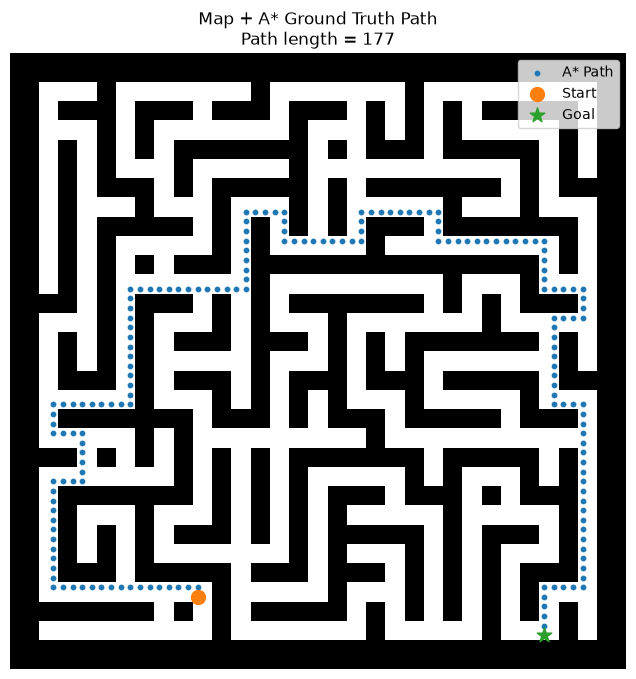

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Load one sample
# ============================================================

sample_path = "dataset/pair_00001.npz"

data = np.load(sample_path)

grid_map = data["map"]       # [3, 64, 64]
path = data["path"]          # [1, 64, 64]

start = data["start"]
goal = data["goal"]
path_length = data["path_length"]


print("Map shape:", grid_map.shape)
print("Path shape:", path.shape)
print("Start:", start)
print("Goal:", goal)
print("A* path length:", path_length)


# ============================================================
# Extract channels
# ============================================================

obstacle = grid_map[0]
start_map = grid_map[1]
goal_map = grid_map[2]

path_map = path[0]


# ============================================================
# Visualize
# ============================================================

plt.figure(figsize=(8, 8))

# 1 = obstacle → black
# 0 = free → white
plt.imshow(
    obstacle,
    cmap="gray_r",
    origin="upper"
)

# Get path coordinates
path_y, path_x = np.where(path_map == 1)

plt.scatter(
    path_x,
    path_y,
    s=10,
    label="A* Path"
)

# Start
plt.scatter(
    start[1],
    start[0],
    s=100,
    marker="o",
    label="Start"
)

# Goal
plt.scatter(
    goal[1],
    goal[0],
    s=120,
    marker="*",
    label="Goal"
)

plt.title(
    f"Map + A* Ground Truth Path\n"
    f"Path length = {int(path_length)}"
)

plt.legend()
plt.axis("off")

plt.show()

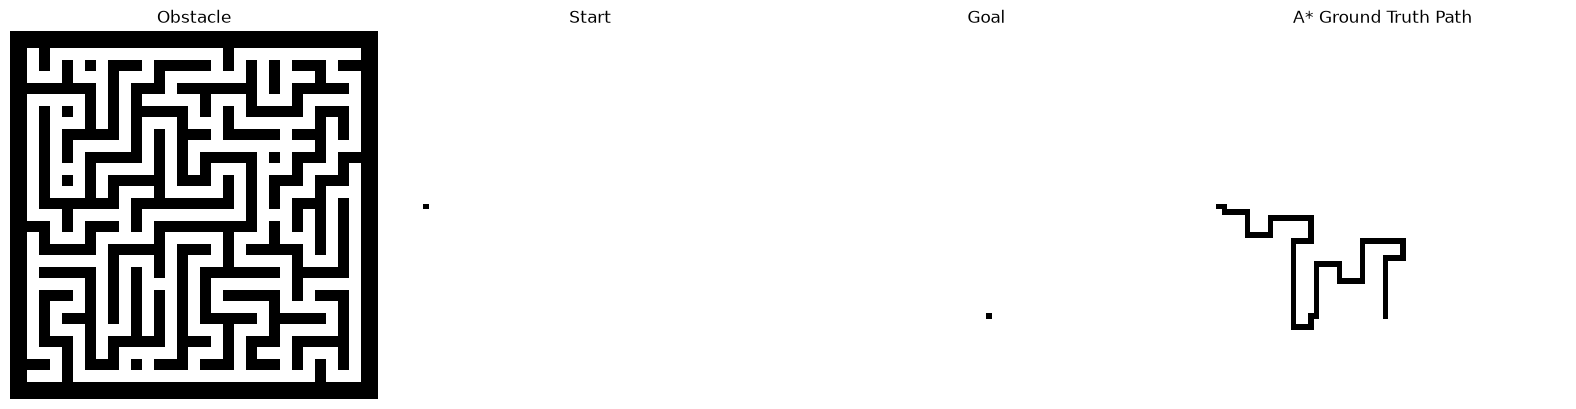

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("dataset/pair_00000.npz")

grid_map = data["map"]
path = data["path"]

obstacle = grid_map[0]
start_map = grid_map[1]
goal_map = grid_map[2]
path_map = path[0]


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(obstacle, cmap="gray_r")
axes[0].set_title("Obstacle")

axes[1].imshow(start_map, cmap="gray_r")
axes[1].set_title("Start")

axes[2].imshow(goal_map, cmap="gray_r")
axes[2].set_title("Goal")

axes[3].imshow(path_map, cmap="gray_r")
axes[3].set_title("A* Ground Truth Path")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()